In [6]:
from __future__ import annotations

import sys
from pathlib import Path

import pandas as pd

In [ ]:
# Pasta de trabalho local (repo root, já commitada — ver ingest_prf_sc.py na raiz)
DATA_DIR = Path("../data_prf_sc")
RAW_DIR = DATA_DIR / "raw"
OUT_DIR = DATA_DIR / "processed"

# Anos a baixar (agrupados por ocorrência). Ajuste conforme necessário —
# quanto mais anos, mais volume para o treino, mas atenção a mudanças de
# metodologia de coleta da PRF ao longo do tempo.
GDRIVE_FILE_IDS: dict[int, str] = {
    2026: "1A3IirNm0AzRaSosA1IS94DOVmvKsn0Ol",
    2025: "1-G3MdmHBt6CprDwcW99xxC4BZ2DU5ryR",
    2024: "14lB0vqMFkaZj8HZ44b0njYgxs9nAN8KO",
    2023: "1-WO3SfNrwwZ5_l7fRTiwBKRw7mi1-HUq",
    2022: "1PRQjuV5gOn_nn6UNvaJyVURDIfbSAK4-",
    2021: "12xH8LX9aN2gObR766YN3cMcuycwyCJDz",
    2020: "1esu6IiH5TVTxFoedv6DBGDd01Gvi8785",
    2019: "1pN3fn2wY34GH6cY-gKfbxRJJBFE0lb_l",
    2018: "1cM4IgGMIiR-u4gBIH5IEe3DcvBvUzedi",
    2017: "1HPLWt5f_l4RIX3tKjI4tUXyZOev52W0N",
}

UF_ALVO = "SC"
BRS_ALVO = {282, 480}

# Aponte aqui para a planilha do SNV baixada manualmente do DNIT/VGEO
SNV_LOCAL_PATH = DATA_DIR / "snv_base.csv"  # .xls também funciona, ver load_snv()

FINAL_OUTPUT_PATH = OUT_DIR / "sinistros_sc_br282_br480.csv"

In [8]:
def download_prf_year(year: int, file_id: str, dest_dir: Path) -> Path:
    """Baixa o CSV de um ano via gdown (lida com a tela de confirmação do Drive)."""
    import gdown

    dest_dir.mkdir(parents=True, exist_ok=True)
    dest = dest_dir / f"acidentes{year}.csv"
    if dest.exists():
        print(f"[{year}] já baixado, pulando.")
        return dest

    url = f"https://drive.google.com/uc?id={file_id}"
    print(f"[{year}] baixando...")
    gdown.download(url, str(dest), quiet=False)
    return dest

In [ ]:
def read_prf_csv(path: Path) -> pd.DataFrame:
    """Le CSV da PRF. Arquivo do Drive vem como .zip (mesmo com extensao .csv
    no nome), às vezes contendo o csv dentro de uma subpasta (ex.: datatran2026/
    datatran2026.csv) — por isso não dá pra usar compression="zip" direto, que
    só aceita zip com um único membro. Extraímos o .csv manualmente."""
    import zipfile

    with open(path, "rb") as f:
        is_zip = f.read(2) == b"PK"

    if is_zip:
        with zipfile.ZipFile(path) as zf:
            csv_names = [n for n in zf.namelist() if n.lower().endswith(".csv")]
            if not csv_names:
                raise ValueError(f"Nenhum .csv encontrado dentro do zip {path}")
            with zf.open(csv_names[0]) as fh:
                return pd.read_csv(
                    fh, sep=";", encoding="latin1", decimal=",", low_memory=False
                )

    return pd.read_csv(
        path,
        sep=";",
        encoding="latin1",
        decimal=",",
        low_memory=False,
    )


def normalize_prf_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Normaliza nomes de coluna: minusculas, sem espaco/acento nas bordas."""
    df = df.copy()
    df.columns = (
        df.columns.str.strip()
        .str.lower()
        .str.normalize("NFKD")
        .str.encode("ascii", errors="ignore")
        .str.decode("ascii")
        .str.replace(" ", "_", regex=False)
    )
    return df

In [10]:
def filter_sc_brs(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    # coluna de km costuma vir como string com vírgula decimal
    if "km" in df.columns:
        df["km"] = pd.to_numeric(
            df["km"].astype(str).str.replace(",", ".", regex=False), errors="coerce"
        )
    if "br" in df.columns:
        df["br"] = pd.to_numeric(df["br"], errors="coerce")

    mask = pd.Series(True, index=df.index)
    if "uf" in df.columns:
        mask &= df["uf"].astype(str).str.upper().str.strip() == UF_ALVO
    if "br" in df.columns:
        mask &= df["br"].isin(BRS_ALVO)
    return df[mask].reset_index(drop=True)

In [11]:
def load_snv(path: Path) -> pd.DataFrame:
    """
    Carrega a planilha do SNV. Ajuste os nomes de coluna abaixo conforme a
    versão baixada (eles variam um pouco entre releases do DNIT).
    Colunas esperadas após normalização: br, uf, km_inicial, km_final,
    superficie, jurisdicao (algumas dessas podem não existir — trate como opcional).
    """
    if not path.exists():
        print(
            f"[aviso] {path} não encontrado — pulando o merge com o SNV. "
            "Baixe a planilha do DNIT/VGEO e aponte SNV_LOCAL_PATH para rodar essa etapa."
        )
        return pd.DataFrame()

    if path.suffix.lower() in {".xls", ".xlsx"}:
        snv = pd.read_excel(path)
    else:
        snv = pd.read_csv(path, sep=None, engine="python")

    snv = normalize_prf_columns(snv)  # mesma limpeza de nomes serve aqui
    return snv


def merge_with_snv(acidentes: pd.DataFrame, snv: pd.DataFrame) -> pd.DataFrame:
    """
    Casa cada acidente ao trecho do SNV cujo intervalo [km_inicial, km_final]
    contém o km do acidente, para o mesmo BR/UF.
    """
    if snv.empty or "km" not in acidentes.columns:
        return acidentes

    required = {"br", "uf", "km_inicial", "km_final"}
    missing = required - set(snv.columns)
    if missing:
        print(f"[aviso] SNV sem as colunas {missing} — confira os nomes reais e ajuste load_snv(). Pulando merge.")
        return acidentes

    snv = snv.copy()
    snv["br"] = pd.to_numeric(snv["br"], errors="coerce")
    snv["km_inicial"] = pd.to_numeric(snv["km_inicial"], errors="coerce")
    snv["km_final"] = pd.to_numeric(snv["km_final"], errors="coerce")

    merged_rows = []
    for (uf, br), grp_acid in acidentes.groupby(["uf", "br"]):
        grp_snv = snv[(snv["uf"].astype(str).str.upper() == str(uf).upper()) & (snv["br"] == br)]
        if grp_snv.empty:
            merged_rows.append(grp_acid)
            continue

        grp_snv = grp_snv.sort_values("km_inicial")
        acids = grp_acid.copy()
        acids["_snv_idx"] = acids["km"].apply(
            lambda k: _find_segment(k, grp_snv) if pd.notnull(k) else None
        )
        acids = acids.merge(
            grp_snv.drop(columns=["br", "uf"]).add_prefix("snv_"),
            left_on="_snv_idx",
            right_index=True,
            how="left",
        ).drop(columns=["_snv_idx"])
        merged_rows.append(acids)

    return pd.concat(merged_rows, ignore_index=True) if merged_rows else acidentes


def _find_segment(km: float, snv_group: pd.DataFrame):
    match = snv_group[(snv_group["km_inicial"] <= km) & (km <= snv_group["km_final"])]
    return match.index[0] if not match.empty else None

## Arquivo Main()

cria as pastas e faz o download das planilhas faltantes
dataset final pronto pra EDA, sinistros de SC nas BR-282/BR-480, ano a ano.

In [15]:
def main() -> None:
    RAW_DIR.mkdir(parents=True, exist_ok=True)
    OUT_DIR.mkdir(parents=True, exist_ok=True)
    FINAL_OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

    frames = []
    for year, file_id in sorted(GDRIVE_FILE_IDS.items()):
        try:
            path = download_prf_year(year, file_id, RAW_DIR)
            df = read_prf_csv(path)
            df = normalize_prf_columns(df)
            df["ano_arquivo"] = year
            df_sc = filter_sc_brs(df)
            print(f"[{year}] {len(df)} registros nacionais -> {len(df_sc)} em SC/BR-282/BR-480")
            frames.append(df_sc)
        except Exception as e:  # noqa: BLE001
            print(f"[{year}] ERRO: {e}", file=sys.stderr)

    if not frames:
        print("Nenhum ano foi processado com sucesso. Abortando.")
        return

    acidentes = pd.concat(frames, ignore_index=True)
    interim_path = OUT_DIR / "acidentes_sc_br282_br480_bruto.csv"
    acidentes.to_csv(interim_path, index=False)
    print(f"\nBase filtrada (sem merge SNV) salva em: {interim_path} ({len(acidentes)} linhas)")

    snv = load_snv(SNV_LOCAL_PATH)
    final = merge_with_snv(acidentes, snv)

    final.to_csv(FINAL_OUTPUT_PATH, index=False)
    print(f"\nDataset final pronto para EDA: {FINAL_OUTPUT_PATH} ({len(final)} linhas, {final.shape[1]} colunas)")

    # resumo rápido, útil como primeiro check da EDA
    print("\nResumo rápido:")
    print(final.dtypes.value_counts())
    print("\nValores nulos por coluna (top 10):")
    print(final.isnull().sum().sort_values(ascending=False).head(10))


if __name__ == "__main__":
    main()

[2017] baixando...


Downloading...
From: https://drive.google.com/uc?id=1HPLWt5f_l4RIX3tKjI4tUXyZOev52W0N
To: c:\faculdade\repos\ML-Sinistros-Rodovias\notebooks\data_prf_sc\raw\acidentes2017.csv
100%|██████████| 4.25M/4.25M [00:01<00:00, 3.15MB/s]


[2017] 89567 registros nacionais -> 1976 em SC/BR-282/BR-480
[2018] baixando...


Downloading...
From: https://drive.google.com/uc?id=1cM4IgGMIiR-u4gBIH5IEe3DcvBvUzedi
To: c:\faculdade\repos\ML-Sinistros-Rodovias\notebooks\data_prf_sc\raw\acidentes2018.csv
100%|██████████| 3.29M/3.29M [00:02<00:00, 1.51MB/s]


[2018] 69333 registros nacionais -> 1563 em SC/BR-282/BR-480
[2019] baixando...


...

[2024] 73156 registros nacionais -> 1510 em SC/BR-282/BR-480
[2025] baixando...


Downloading...
From: https://drive.google.com/uc?id=1-G3MdmHBt6CprDwcW99xxC4BZ2DU5ryR
To: c:\faculdade\repos\ML-Sinistros-Rodovias\notebooks\data_prf_sc\raw\acidentes2025.csv
100%|██████████| 3.73M/3.73M [00:04<00:00, 908kB/s] 


[2025] 72529 registros nacionais -> 1437 em SC/BR-282/BR-480
[2026] baixando...


Downloading...
From: https://drive.google.com/uc?id=1A3IirNm0AzRaSosA1IS94DOVmvKsn0Ol
To: c:\faculdade\repos\ML-Sinistros-Rodovias\notebooks\data_prf_sc\raw\acidentes2026.csv
100%|██████████| 1.39M/1.39M [00:01<00:00, 1.35MB/s]
[2026] ERRO: Multiple files found in ZIP file. Only one file per ZIP: ['datatran2026/', 'datatran2026/datatran2026.csv']



Base filtrada (sem merge SNV) salva em: data_prf_sc\processed\acidentes_sc_br282_br480_bruto.csv (12965 linhas)
[aviso] data_prf_sc\snv_base.csv não encontrado — pulando o merge com o SNV. Baixe a planilha do DNIT/VGEO e aponte SNV_LOCAL_PATH para rodar essa etapa.

Dataset final pronto para EDA: data_prf_sc\processed\sinistros_sc_br282_br480.csv (12965 linhas, 31 colunas)

Resumo rápido:
str        17
int64      10
float64     2
object      2
Name: count, dtype: int64

Valores nulos por coluna (top 10):
id                0
data_inversa      0
dia_semana        0
horario           0
uf                0
br                0
km                0
municipio         0
causa_acidente    0
tipo_acidente     0
dtype: int64


## Gráficos exploratórios

Painel rápido sobre a base já filtrada (SC / BR-282 / BR-480), pra primeira leitura antes da EDA completa.

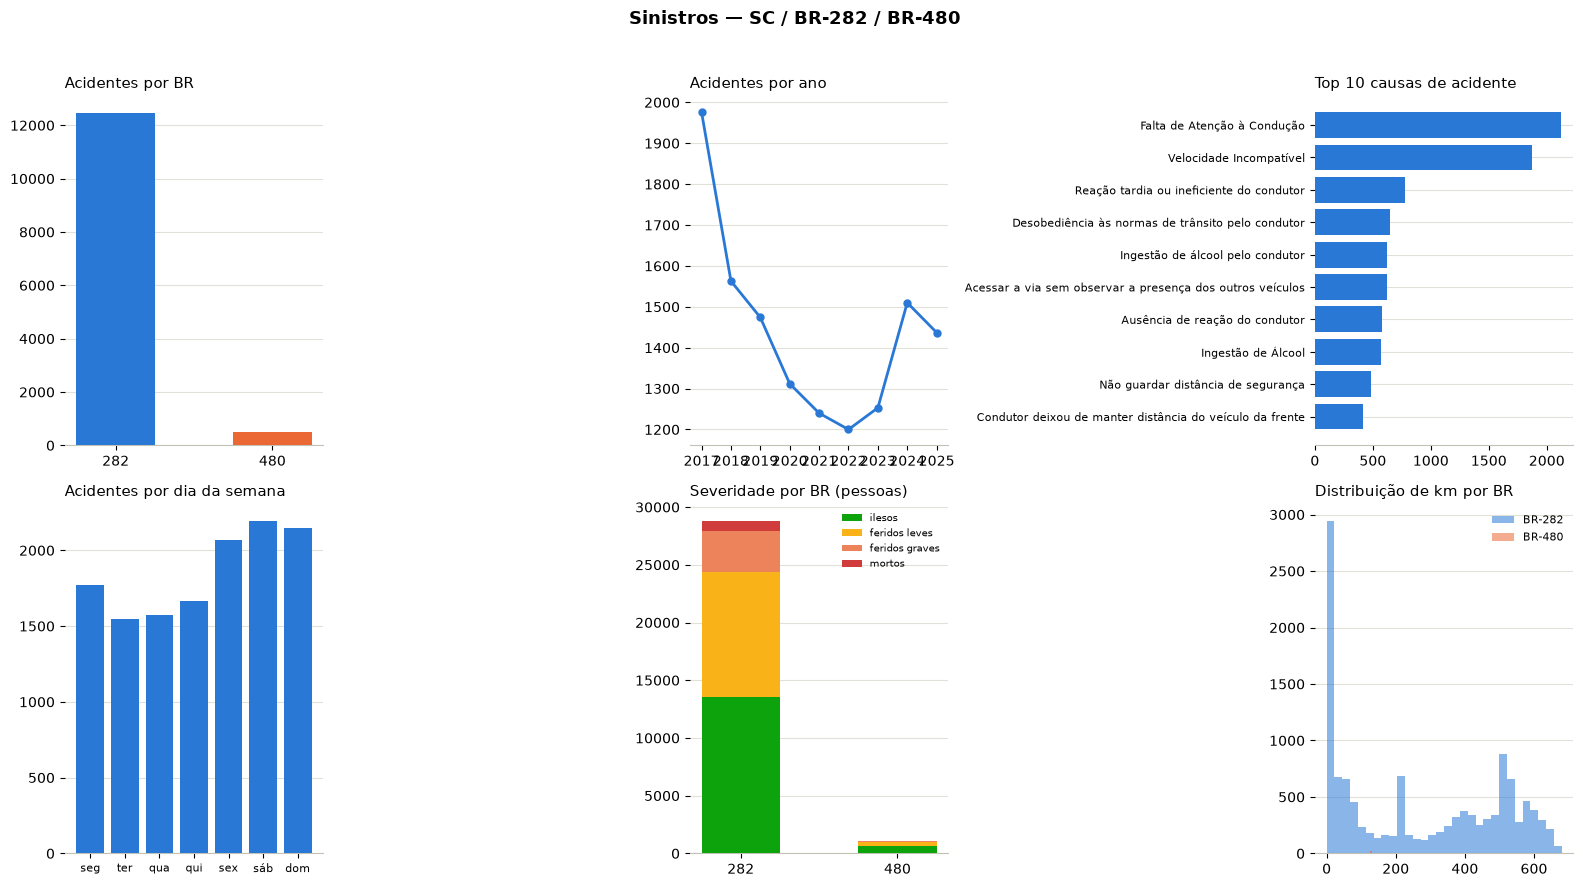

In [16]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Paleta fixa (evita cor "no chute" e evita rainbow)
COLOR_BLUE = "#2a78d6"    # sequencial / categórico slot 1
COLOR_ORANGE = "#eb6834"  # categórico slot 2
COLOR_GOOD = "#0ca30c"     # ilesos
COLOR_WARNING = "#fab219"  # feridos leves
COLOR_SERIOUS = "#ec835a"  # feridos graves
COLOR_CRITICAL = "#d03b3b"  # mortos
GRID_COLOR = "#e1e0d9"
BR_ORDER = [282, 480]
BR_COLORS = {282: COLOR_BLUE, 480: COLOR_ORANGE}
DIAS_ORDEM = [
    "segunda-feira", "terça-feira", "quarta-feira", "quinta-feira",
    "sexta-feira", "sábado", "domingo",
]


def _style_ax(ax, title: str) -> None:
    ax.set_title(title, fontsize=11, loc="left")
    ax.grid(axis="y", color=GRID_COLOR, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    for spine in ("top", "right", "left"):
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color("#c3c2b7")


def plot_overview(df: pd.DataFrame) -> None:
    if df.empty:
        print("Base vazia — nada para plotar.")
        return

    fig, axes = plt.subplots(2, 3, figsize=(16, 9))

    # 1) Acidentes por BR
    ax = axes[0, 0]
    contagem_br = df["br"].value_counts().reindex(BR_ORDER).fillna(0)
    ax.bar(
        [str(int(b)) for b in contagem_br.index],
        contagem_br.values,
        color=[BR_COLORS[b] for b in contagem_br.index],
        width=0.5,
        zorder=3,
    )
    _style_ax(ax, "Acidentes por BR")

    # 2) Evolução por ano (se ano_arquivo existir)
    ax = axes[0, 1]
    if "ano_arquivo" in df.columns:
        por_ano = df.groupby("ano_arquivo").size().sort_index()
        ax.plot(por_ano.index, por_ano.values, color=COLOR_BLUE, linewidth=2, marker="o", markersize=5, zorder=3)
        ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    else:
        ax.text(0.5, 0.5, "sem coluna ano_arquivo", ha="center", va="center", transform=ax.transAxes)
    _style_ax(ax, "Acidentes por ano")

    # 3) Top 10 causas
    ax = axes[0, 2]
    if "causa_acidente" in df.columns:
        top_causas = df["causa_acidente"].value_counts().head(10).sort_values()
        ax.barh(top_causas.index, top_causas.values, color=COLOR_BLUE, zorder=3)
        ax.tick_params(axis="y", labelsize=8)
    else:
        ax.text(0.5, 0.5, "sem coluna causa_acidente", ha="center", va="center", transform=ax.transAxes)
    _style_ax(ax, "Top 10 causas de acidente")

    # 4) Acidentes por dia da semana
    ax = axes[1, 0]
    if "dia_semana" in df.columns:
        dia_norm = df["dia_semana"].astype(str).str.lower().str.strip()
        presentes = [d for d in DIAS_ORDEM if d in dia_norm.unique()]
        ordem = presentes if presentes else sorted(dia_norm.unique())
        contagem_dia = dia_norm.value_counts().reindex(ordem).fillna(0)
        ax.bar(range(len(contagem_dia)), contagem_dia.values, color=COLOR_BLUE, zorder=3)
        ax.set_xticks(range(len(contagem_dia)))
        ax.set_xticklabels([d[:3] for d in contagem_dia.index], rotation=0, fontsize=8)
    else:
        ax.text(0.5, 0.5, "sem coluna dia_semana", ha="center", va="center", transform=ax.transAxes)
    _style_ax(ax, "Acidentes por dia da semana")

    # 5) Severidade por BR (pessoas ilesas / feridas / mortas)
    ax = axes[1, 1]
    severidade_cols = ["ilesos", "feridos_leves", "feridos_graves", "mortos"]
    disponiveis = [c for c in severidade_cols if c in df.columns]
    if disponiveis and "br" in df.columns:
        sev_por_br = df.groupby("br")[disponiveis].sum().reindex(BR_ORDER).fillna(0)
        cores = {"ilesos": COLOR_GOOD, "feridos_leves": COLOR_WARNING,
                 "feridos_graves": COLOR_SERIOUS, "mortos": COLOR_CRITICAL}
        x = range(len(sev_por_br))
        bottom = [0] * len(sev_por_br)
        for col in disponiveis:
            ax.bar(x, sev_por_br[col], bottom=bottom, label=col.replace("_", " "),
                   color=cores[col], width=0.5, zorder=3)
            bottom = [b + v for b, v in zip(bottom, sev_por_br[col])]
        ax.set_xticks(list(x))
        ax.set_xticklabels([str(int(b)) for b in sev_por_br.index])
        ax.legend(fontsize=7, frameon=False, loc="upper right")
    else:
        ax.text(0.5, 0.5, "colunas de severidade ausentes", ha="center", va="center", transform=ax.transAxes)
    _style_ax(ax, "Severidade por BR (pessoas)")

    # 6) Distribuição de km por BR
    ax = axes[1, 2]
    if "km" in df.columns and "br" in df.columns:
        for br in BR_ORDER:
            valores = df.loc[df["br"] == br, "km"].dropna()
            if not valores.empty:
                ax.hist(valores, bins=30, color=BR_COLORS[br], alpha=0.55, label=f"BR-{br}", zorder=3)
        ax.legend(fontsize=8, frameon=False)
    else:
        ax.text(0.5, 0.5, "sem colunas km/br", ha="center", va="center", transform=ax.transAxes)
    _style_ax(ax, "Distribuição de km por BR")

    fig.suptitle("Sinistros — SC / BR-282 / BR-480", fontsize=13, fontweight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


if FINAL_OUTPUT_PATH.exists():
    _df_plot = pd.read_csv(FINAL_OUTPUT_PATH)
    plot_overview(_df_plot)
else:
    print(f"{FINAL_OUTPUT_PATH} não existe ainda — rode main() primeiro.")